# Setup e Imports

In [5]:
import os
import operator
from typing import Annotated, List, Union, Literal
from dotenv import load_dotenv

# --- LangChain & OpenAI ---
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from pydantic import BaseModel, Field 

# --- RAG & Almacenamiento ---
from langchain_chroma import Chroma
from langchain_community.document_loaders import DirectoryLoader, UnstructuredMarkdownLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.agents import AgentExecutor, create_tool_calling_agent

# --- Orquestación (LangGraph) ---
from langgraph.graph import StateGraph, END

# --- Observabilidad & Visualización ---
from langfuse.callback import CallbackHandler
from IPython.display import Image, display

# --- Cargar entorno ---
load_dotenv()

# --- Configuración Global (Constants) ---
CHROMA_PATH = "chroma_db"
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

## Integración con LangFuse

In [6]:
langfuse_handler = CallbackHandler(
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    host=os.getenv("LANGFUSE_HOST")
)

# Prueba de conexión
if langfuse_handler.auth_check():
    print("✅ Conexión con Langfuse exitosa. ¡Estamos trazando!")
else:
    print("❌ Error de conexión. Revisa tus API Keys.")

✅ Conexión con Langfuse exitosa. ¡Estamos trazando!


## Carga de Documentos y Vector Stores

In [7]:
def create_vector_store(domain_name):
    print(f"--- Procesando dominio: {domain_name} ---")
    
    loader = DirectoryLoader(
        f"./data/{domain_name}_docs", 
        glob="**/*.md", 
        loader_cls=UnstructuredMarkdownLoader
    )
    docs = loader.load()
    print(f"Documentos cargados: {len(docs)}")

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
        add_start_index=True
    )
    chunks = text_splitter.split_documents(docs)
    print(f"Fragmentos creados: {len(chunks)}")

    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=CHROMA_PATH,
        collection_name=f"{domain_name}_collection"
    )
    
    print(f"✅ Dominio {domain_name} indexado correctamente.\n")
    return vector_store

booking_db = create_vector_store("booking")
logistics_db = create_vector_store("logistics")
marketing_db = create_vector_store("marketing")

--- Procesando dominio: booking ---
Documentos cargados: 10
Fragmentos creados: 52
✅ Dominio booking indexado correctamente.

--- Procesando dominio: logistics ---
Documentos cargados: 10
Fragmentos creados: 50
✅ Dominio logistics indexado correctamente.

--- Procesando dominio: marketing ---
Documentos cargados: 10
Fragmentos creados: 56
✅ Dominio marketing indexado correctamente.



## Definimos las TOOLS

#### Calculadora de Nafta y Clima

In [8]:
from langchain_core.tools import tool

@tool
def calculate_travel_costs(distance_km: float, consumption_per_100km: float = 10.0, fuel_price: float = 1100.0):
    """
    Calcula el costo estimado de combustible para un viaje.
    distance_km: Distancia total del viaje en kilómetros.
    consumption_per_100km: Litros que consume el vehículo cada 100km (defecto 10.0 para una Partner/Kangoo).
    fuel_price: Precio actual del litro de nafta en Argentina.
    """
    liters_needed = (distance_km / 100) * consumption_per_100km
    total_cost = liters_needed * fuel_price
    
    return {
        "liters_needed": round(liters_needed, 2),
        "estimated_cost_ars": round(total_cost, 2),
        "notes": "Cálculo basado en consumo promedio y precios actuales."
    }

@tool
def get_weather_forecast(city: str):
    """Simula el pronóstico del tiempo para una ciudad."""
    # Aquí voy a conectar una API real como OpenWeatherMap en el futuro
    return f"El pronóstico para {city} es de 24°C, despejado. Ideal para cargar instrumentos o tocar al aire libre."

## Definición del ORQUESTADOR

In [9]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 1. Definición del Esquema de Salida (Contrato de Datos)
class RouteQuery(BaseModel):
    """Ruta la consulta del usuario al experto más adecuado basándose en el dominio."""
    topic: Literal["booking", "logistics", "marketing", "weather"] = Field(
        description="El dominio experto para la consulta: booking, logistics, marketing o weather."
    )

# 2. Configuración del LLM y el Router Estructurado
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

# 3. Prompt de Sistema (Instrucciones de Razonamiento)
system_prompt = """Eres el Tour Manager Senior de BeatSync. 
Tu función es clasificar las consultas de los artistas en uno de los siguientes departamentos:

1. BOOKING: Bares, locales, centros culturales, festivales, disponibilidad de fechas o cachets.
2. LOGISTICS: Rutas, distancias, cálculos de nafta/consumo y hoteles con cochera segura.
3. MARKETING: Gacetillas de prensa, promoción en redes, mensajes para radios y planes de difusión.
4. WEATHER: Clima, pronóstico meteorológico y condiciones para eventos al aire libre.

Analiza cuidadosamente la intención del usuario y responde ÚNICAMENTE con el tópico en formato JSON."""

route_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{question}"),
])

# 4. Creación de la Cadena (Chain)
question_router = route_prompt | structured_llm_router

## Definición de AGENTES
#### RAG Chain + Agent con Tools

In [10]:
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import MessagesPlaceholder

# --- Función para agentes RAG puros (Booking, Marketing) ---
def create_rag_chain(db, system_instruction):
    agent_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    retriever = db.as_retriever(search_kwargs={"k": 3})
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_instruction + "\n\nContexto extraído:\n{context}"),
        ("human", "{input}"),
    ])
    
    combine_docs_chain = create_stuff_documents_chain(agent_llm, prompt)
    return create_retrieval_chain(retriever, combine_docs_chain)

# --- Función para agente con Tools (Logística) ---
def create_agent_with_tools(db, system_instruction, tools):
    agent_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_instruction + "\nTienes acceso a herramientas especializadas. Úsalas cuando sea apropiado."),
        ("human", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad"),
    ])
    
    agent = create_tool_calling_agent(agent_llm, tools, prompt)
    return AgentExecutor(agent=agent, tools=tools, verbose=True)

# --- INSTRUCCIONES DE PERSONALIDAD ---
booking_instruction = "Eres el Agente de Booking de TourMaster. Tu meta es encontrar los mejores bares y fechas. Sé profesional y directo."
logistics_instruction = "Eres el Experto en Logística de TourMaster. Ayuda a bandas con rutas, cálculos de combustible y hospedajes con cochera. Cuando te pregunten por costos de viaje o nafta, USA SIEMPRE la herramienta calculate_travel_costs."
marketing_instruction = "Eres el Gurú de Marketing Musical. Crea gacetillas de prensa y planes de redes sociales que emocionen."

# --- CREACIÓN DE LOS AGENTES ---
booking_agent = create_rag_chain(booking_db, booking_instruction)
logistics_agent = create_agent_with_tools(logistics_db, logistics_instruction, tools=[calculate_travel_costs])
marketing_agent = create_rag_chain(marketing_db, marketing_instruction)

print("✅ Agentes creados correctamente")
print("   - Booking: RAG Chain")
print("   - Logistics: Agent con Tools (calculate_travel_costs)")
print("   - Marketing: RAG Chain")

✅ Agentes creados correctamente
   - Booking: RAG Chain
   - Logistics: Agent con Tools (calculate_travel_costs)
   - Marketing: RAG Chain


#### Creamos una función para guardar el estado e historial de mensajes

In [11]:
from typing import TypedDict, Annotated, List, Union
import operator

class AgentState(TypedDict):
    messages: Annotated[List[dict], operator.add]
    next_node: str
    query: str
    answer: str
    expert_used: str

## Definición de los NODOS

In [12]:
def orchestrator_node(state: AgentState):
    res = question_router.invoke({"question": state["query"]})
    chosen_topic = res.topic.lower()
    print(f"🧠 [ORQUESTADOR]: Clasificando como experto en {chosen_topic.upper()}")
    return {
        "next_node": chosen_topic,
        "expert_used": chosen_topic.upper()
    }

def booking_node(state: AgentState):
    res = booking_agent.invoke({"input": state["query"]})
    return {"answer": res["answer"], "expert_used": "BOOKING"}

def logistics_node(state: AgentState):
    res = logistics_agent.invoke({"input": state["query"]})
    return {"answer": res["output"], "expert_used": "LOGISTICS"}

def marketing_node(state: AgentState):
    res = marketing_agent.invoke({"input": state["query"]})
    return {"answer": res["answer"], "expert_used": "MARKETING"}

llm_weather = ChatOpenAI(model="gpt-4o-mini").bind_tools([get_weather_forecast])

def weather_node(state: AgentState):
    res = llm_weather.invoke(state["query"])
    
    if res.tool_calls:
        forecast = get_weather_forecast.invoke(res.tool_calls[0]["args"])
        return {"answer": f"Pronóstico: {forecast}", "expert_used": "WEATHER"}
    
    return {"answer": res.content, "expert_used": "WEATHER"}

## Definición del EVALUATOR

In [13]:
from pydantic import BaseModel, Field

class EvaluationScore(BaseModel):
    """Puntaje de calidad de la respuesta de la IA."""
    score: int = Field(description="Puntaje del 1 al 10")
    reason: str = Field(description="Breve explicación del porqué del puntaje")

evaluator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(EvaluationScore)

def evaluator_node(state: AgentState):
    """Evalúa la calidad de la respuesta generada."""
    query = state["query"]
    answer = state["answer"]
    
    eval_prompt = f"""
    Eres un auditor de calidad de IA. 
    Evalúa la siguiente respuesta basándote en la consulta original.
    
    CONSULTA: {query}
    RESPUESTA GENERADA: {answer}
    
    Debes puntuar del 1 al 10 basándote en:
    - Precisión: ¿Responde lo que se pidió?
    - Fundamentación: ¿Se nota que usó datos (bares, hoteles, cálculos)?
    - Tono: ¿Es profesional y útil?
    """
    
    evaluation = evaluator_llm.invoke(eval_prompt)
    
    langfuse_handler.langfuse.score(
        name="answer-quality",  
        value=evaluation.score,
        comment=evaluation.reason
    )
    
    print(f"⚗️ Evaluación: {evaluation.score}/10 - {evaluation.reason}")
    return {"messages": [("ai", f"Calidad: {evaluation.score}/10")]}

## Contrucción del Grafo
 Se utiliza Conditional Edge (Enrutamiento condicional) para el Orquestador elija al agente experto que crea conveniente.
 Importamos StateGraph de LangGraph.

In [14]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

workflow.add_node("orchestrator", orchestrator_node)
workflow.add_node("booking", booking_node)
workflow.add_node("logistics", logistics_node)
workflow.add_node("marketing", marketing_node)
workflow.add_node("weather", weather_node) 
workflow.add_node("evaluator", evaluator_node) 

workflow.set_entry_point("orchestrator")

workflow.add_conditional_edges(
    "orchestrator",
    lambda state: state["next_node"],
    {
        "booking": "booking",
        "logistics": "logistics",
        "marketing": "marketing",
        "weather": "weather"    
    }
)

workflow.add_edge("booking", "evaluator")
workflow.add_edge("logistics", "evaluator")
workflow.add_edge("marketing", "evaluator")
workflow.add_edge("weather", "evaluator")

workflow.add_edge("evaluator", END)

app = workflow.compile()
print("✅ Grafo de TourMaster compilado correctamente")

✅ Grafo de TourMaster compilado correctamente


## VER el GRÁFICO

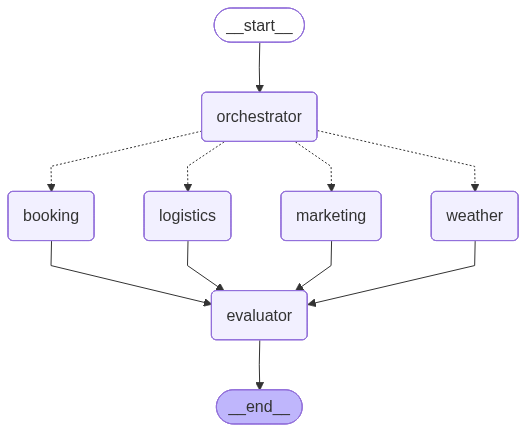

In [15]:
from IPython.display import Image, display

try:
    # Genera el diagrama usando Mermaid (formato estándar de grafos)
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # Si falta alguna librería de dibujo, nos da una versión en texto (ASCII)
    print(app.get_graph().print_ascii())

## Función para ejecutar todo el sistema

In [16]:
def run_tourmaster_graph(query: str):
    """
    Punto de entrada principal para el sistema TourMaster.
    Carga el estado inicial y ejecuta el grafo compilado.
    """
    inputs = {
        "query": query, 
        "messages": []
    }
    
    config = {"callbacks": [langfuse_handler]}
    final_state = app.invoke(inputs, config=config)
    
    expert = final_state.get('expert_used', 'DESCONOCIDO')
    
    print(f"\n{'='*70}")
    print(f"💡 TOURMASTER AI - RESPUESTA DEL EXPERTO EN {expert}")
    print(f"{'='*70}")
    print(f"Pregunta: {query}")
    print(f"\nRespuesta:\n{final_state['answer']}")
    print(f"{'='*70}\n")
    
    return final_state

In [17]:
print(run_tourmaster_graph("Podrias darme informacion sobre 3 bares en Córdoba que contraten bandas de Rock?"))

🧠 [ORQUESTADOR]: Clasificando como experto en BOOKING
⚗️ Evaluación: 9/10 - La respuesta es precisa y proporciona información relevante sobre tres bares en Córdoba que contratan bandas de Rock, incluyendo géneros, capacidad y contacto. Sin embargo, no se menciona si la información está actualizada o verificada, lo que podría mejorar la fundamentación.

💡 TOURMASTER AI - RESPUESTA DEL EXPERTO EN BOOKING
Pregunta: Podrias darme informacion sobre 3 bares en Córdoba que contraten bandas de Rock?

Respuesta:
Claro, aquí tienes información sobre tres bares en Córdoba que contratan bandas de Rock:

1. **Club Paraguay**
   - **Géneros:** Rock, Indie
   - **Capacidad:** 300 personas
   - **Contacto:** [clubparaguay.com](http://clubparaguay.com) | Tel: +54 351 123-4567

2. **El Kuelgue**
   - **Géneros:** Rock, Indie, DJ
   - **Capacidad:** 500 personas
   - **Contacto:** [elkuelgue.com](http://elkuelgue.com) | Tel: +54 351 987-6543

3. **La Trastienda Sur**
   - **Géneros:** Rock, Pop, Acústico